# 3.3.2 概率推断与 TEI 统计分析

## 目标
1. 全场批量 MC Dropout 推理（DataLoader batch_size=256）
2. 全场 TEI 时序曲线（标注进球/换人事件）
3. TEI 按战术情境分组统计（箱线图 + Mann-Whitney U 检验）
4. B-GNN Top-1 vs EFPI 一致性分析
5. 高 TEI 帧事件研究法（Event Study）
6. 时间相干性分析（JSD）

## 1. 环境设置与导入

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.stats import mannwhitneyu
import pickle, json
from pathlib import Path
from datetime import timedelta
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

Using device: cpu


## 2. 加载数据

In [2]:
base_path = Path(r"E:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH")
data_path = base_path / "data" / "morph_test" / "bgnn_dataset"
model_path = base_path / "Step3_Probabilistic_Identification" / "3.2_Probabilistic_Model" / "Test" / "best_model.pth"
out_dir = base_path / "data" / "morph_test" / "bgnn_analysis"
out_dir.mkdir(parents=True, exist_ok=True)

with open(data_path / "graph_dataset_10517_full.pkl", "rb") as f:
    all_graphs = pickle.load(f)
all_graphs = [g for g in all_graphs if not torch.isnan(g.x).any()]
print(f"有效图数量: {len(all_graphs)}")

with open(data_path / "dataset_metadata_10517_full.json") as f:
    metadata = json.load(f)
num_classes = metadata["n_formations"]

with open(base_path / "data" / "morph_test" / "bgnn_data" / "formation_mapping.pkl", "rb") as f:
    formation_mapping = pickle.load(f)
idx_to_formation = formation_mapping["idx_to_formation"]

tracking_pl = pl.read_parquet(base_path / "data" / "morph_test" / "tracking_data_10517_tactical_labels.parquet")
efpi_pl = pl.read_parquet(base_path / "data" / "morph_test" / "efpi_baseline" / "efpi_baseline_results_10517_fullmatch.parquet")

HOME_TEAM_ID = '364'
# 从图数据集动态读取维度（避免硬编码导致与 best_model.pth 不匹配）
sample_g = all_graphs[0]
node_feature_dim   = sample_g.x.shape[1]               # 节点特征维度（41）
global_feature_dim = sample_g.global_features.shape[-1] # 全局特征维度（22 或 24）
hidden_dim         = 128
print(f"n_formations={num_classes}, tracking={tracking_pl.shape[0]}行, EFPI={efpi_pl.shape[0]}行")

有效图数量: 49928
n_formations=65, tracking=2966182行, EFPI=2966182行


## 3. 模型定义与加载

In [3]:
# ── 紧凑版 BGNN（与 best_model.pth state_dict key 完全匹配）──────────────────
class GraphConvModule(nn.Module):
    def __init__(self, ic, hc, oc):
        super().__init__()
        self.c1, self.b1 = GCNConv(ic, hc), nn.BatchNorm1d(hc)
        self.c2, self.b2 = GCNConv(hc, oc), nn.BatchNorm1d(oc)
    def forward(self, x, ei):
        x = F.relu(self.b1(self.c1(x, ei)))
        x = F.dropout(x, p=0.3, training=self.training)
        return self.b2(self.c2(x, ei))

class GlobalFeatureFusion(nn.Module):
    def __init__(self, gd, gl, fd):
        super().__init__()
        self.fg = nn.Linear(gd, fd)  # graph embedding -> fusion
        self.fl = nn.Linear(gl, fd)  # global features -> fusion
        self.bn = nn.BatchNorm1d(fd)
    def forward(self, ge, gf):
        if gf.dim() == 3: gf = gf.squeeze(1)
        return F.relu(self.bn(self.fg(ge) + self.fl(gf)))

class MCDropout(nn.Module):
    def __init__(self, p=0.5): super().__init__(); self.p = p
    def forward(self, x): return F.dropout(x, p=self.p, training=True)

class BGNN(nn.Module):
    def __init__(self, nd, gd, hd, nc):
        super().__init__()
        self.gcm = GraphConvModule(nd, hd, hd)
        self.fus = GlobalFeatureFusion(hd, gd, hd)
        self.mcd = MCDropout(0.5)
        self.cls = nn.Sequential(
            nn.Linear(hd, hd), nn.ReLU(), nn.Dropout(0.3), nn.Linear(hd, nc)
        )
    def forward(self, data):
        ne = self.gcm(data.x, data.edge_index)
        ge = global_mean_pool(ne, data.batch)
        z  = self.fus(ge, data.global_features)
        return self.cls(self.mcd(z))
    def embed(self, data):
        """确定性嵌入（关闭 MCDropout），用于原型计算"""
        ne = self.gcm(data.x, data.edge_index)
        ge = global_mean_pool(ne, data.batch)
        return self.fus(ge, data.global_features)  # z_t, shape (batch, hd)
    def embed_mc(self, data):
        """MC Dropout 嵌入（推断期 Dropout 恒激活），用于不确定性估计"""
        ne = self.gcm(data.x, data.edge_index)
        ge = global_mean_pool(ne, data.batch)
        return F.dropout(self.fus(ge, data.global_features), p=0.5, training=True)

model = BGNN(node_feature_dim, global_feature_dim, hidden_dim, num_classes).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f'模型加载完成 | 参数量: {sum(p.numel() for p in model.parameters()):,}')
print(f'  fus.fl.weight shape: {model.fus.fl.weight.shape}  '
      f'(期望 [{hidden_dim}, {global_feature_dim}])')

模型加载完成 | 参数量: 67,265
  fus.fl.weight shape: torch.Size([128, 24])  (期望 [128, 24])


## 4. 全场批量 MC Dropout 推理

In [4]:
N_SAMPLES = 50
BATCH_SIZE = 256

loader = DataLoader(all_graphs, batch_size=BATCH_SIZE, shuffle=False)

all_frame_ids, all_probs, all_tei = [], [], []

print("全场批量推理中...")
with torch.no_grad():
    for batch_data in tqdm(loader):
        batch_data = batch_data.to(device)
        probs_list = []
        for _ in range(N_SAMPLES):
            logits = model(batch_data)
            probs_list.append(torch.softmax(logits, dim=-1))
        probs = torch.stack(probs_list).mean(0)  # [B, num_classes]
        tei = -torch.sum(probs * torch.log2(probs + 1e-8), dim=-1)  # [B]

        # frame_id 可能是 tensor 或 list，统一转为 list
        raw_fids = batch_data.frame_id if hasattr(batch_data, "frame_id") else None
        if raw_fids is None:
            fids = [0] * probs.shape[0]
        elif isinstance(raw_fids, torch.Tensor):
            fids = raw_fids.cpu().numpy().tolist()
        elif isinstance(raw_fids, list):
            fids = [f.item() if isinstance(f, torch.Tensor) else int(f) for f in raw_fids]
        else:
            fids = list(raw_fids)

        all_frame_ids.extend(fids)
        all_probs.append(probs.cpu().numpy())
        all_tei.extend(tei.cpu().numpy().tolist())

all_probs_np = np.vstack(all_probs)  # [N, num_classes]
print(f"推理完成: {len(all_frame_ids)} 帧")

全场批量推理中...


100%|██████████| 196/196 [01:58<00:00,  1.65it/s]

推理完成: 49928 帧


## 5. 构建 TEI 时序 DataFrame

In [5]:
# 每帧取阿根廷外场球员第一行的战术标签
frame_meta = (
    tracking_pl
    .filter(
        (pl.col("team_id") == HOME_TEAM_ID)
        & (pl.col("id") != "ball")
        & (pl.col("position_name") != "GK")
    )
    .group_by("frame_id")
    .agg([
        pl.first("period_id").alias("period_id"),
        pl.first("timestamp").alias("timestamp"),
        pl.first("macro_phase").alias("macro_phase"),
        pl.first("fine_intent").alias("fine_intent"),
    ])
)

efpi_home = efpi_pl.filter(pl.col("team_id") == HOME_TEAM_ID).select(["frame_id", "formation"])

top1_idx = np.argmax(all_probs_np, axis=1)
top1_prob = all_probs_np[np.arange(len(top1_idx)), top1_idx]
top1_formation = [idx_to_formation.get(int(i), str(i)) for i in top1_idx]

result_df = pl.DataFrame({
    "frame_id": [int(f) for f in all_frame_ids],
    "tei": all_tei,
    "top1_formation": top1_formation,
    "top1_prob": top1_prob.tolist(),
})

result_df = (
    result_df
    .join(frame_meta, on="frame_id", how="left")
    .join(efpi_home.rename({"formation": "efpi_formation"}), on="frame_id", how="left")
    .sort("frame_id")
)

def ts_to_sec(ts):
    if ts is None:
        return None
    return ts.total_seconds() if isinstance(ts, timedelta) else float(ts)

result_df = result_df.with_columns(
    pl.col("timestamp").map_elements(ts_to_sec, return_dtype=pl.Float64).alias("time_sec")
)

result_df.write_parquet(out_dir / "tei_timeseries_10517.parquet")
print(f"保存: tei_timeseries_10517.parquet, shape={result_df.shape}")
print(result_df.head(3))

保存: tei_timeseries_10517.parquet, shape=(549208, 10)
shape: (3, 10)
┌──────────┬──────────┬────────────┬───────────┬───┬────────────┬───────────┬───────────┬──────────┐
│ frame_id ┆ tei      ┆ top1_forma ┆ top1_prob ┆ … ┆ macro_phas ┆ fine_inte ┆ efpi_form ┆ time_sec │
│ ---      ┆ ---      ┆ tion       ┆ ---       ┆   ┆ e          ┆ nt        ┆ ation     ┆ ---      │
│ i64      ┆ f64      ┆ ---        ┆ f64       ┆   ┆ ---        ┆ ---       ┆ ---       ┆ f64      │
│          ┆          ┆ str        ┆           ┆   ┆ str        ┆ str       ┆ str       ┆          │
╞══════════╪══════════╪════════════╪═══════════╪═══╪════════════╪═══════════╪═══════════╪══════════╡
│ 4630     ┆ 1.777544 ┆ 2431       ┆ 0.758474  ┆ … ┆ Out-of-Pos ┆ MID_BLOCK ┆ 2431      ┆ 0.000821 │
│          ┆          ┆            ┆           ┆   ┆ session    ┆           ┆           ┆          │
│          ┆          ┆            ┆           ┆   ┆ Open Play  ┆           ┆           ┆          │
│ 4630     ┆ 1.777544 ┆

## 6. 全场 TEI 时序曲线

进球: 6 | 黄牌: 7 | 换人: 13
  P1 22.4min (1342s) | ARG 1-0 (22:22) Messi
  P1 35.4min (2121s) | ARG 2-0 (35:21) María
  P2 34.4min (2064s) | FRA 1-2 (79:24) Mbappé
  P2 36.0min (2158s) | FRA 2-2 (80:58) Mbappé
  P4 3.0min (177s) | ARG 3-2 (107:57) Messi
  P4 12.1min (724s) | FRA 3-3 (117:04) Mbappé
数据包含 period: [np.int64(1)]（图数据集仅覆盖部分 period 属正常现象）


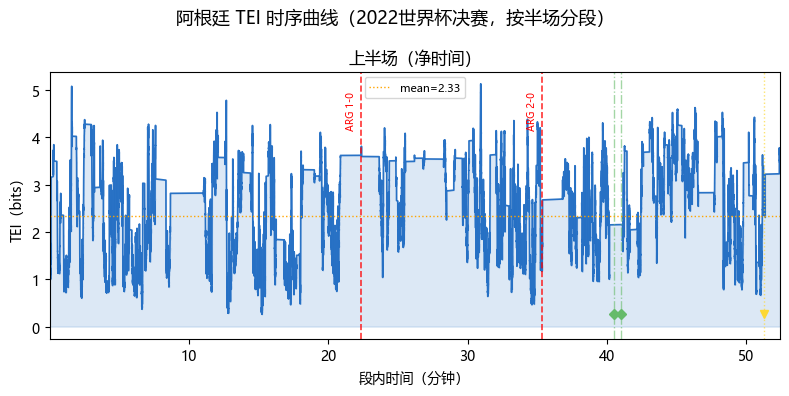

上半场 均值 TEI=2.326 bits
全场均值 TEI=2.326 bits


In [6]:
import json as _json_ev

def _load_events(game_id=10517):
    """从 Event Data JSON 动态加载进球/黄牌/换人，period_starts 由踢球事件确定"""
    ev_path = (Path(r'E:\JerryWu\Master\SoccerAnalytics\OpenData\TrackingData'
                    r'\Gradient Sports  Enhanced 2022 World Cup Dataset\Event Data')
               / f'{game_id}.json')
    period_starts = {1: 0, 2: 2700, 3: 5400, 4: 6300}  # 各半场累积偏移（秒）
    with open(ev_path, 'r', encoding='utf-8') as _f:
        _ev = _json_ev.load(_f)
    goals_raw, yellows, subs = [], [], []
    for e in _ev:
        ge = e.get('gameEvents', {})
        pe = e.get('possessionEvents', {}) or {}
        fo = e.get('fouls', {}) or {}
        period = ge.get('period')
        if period not in period_starts:
            continue
        abs_clock = ge.get('startGameClock') or 0
        ts = abs_clock - period_starts[period]  # 段内秒数
        fmt = ge.get('startFormattedGameClock', '')
        team = ge.get('teamName', '') or ''
        # 进球（排除点球大战：P4 超过 120' = abs_clock > 7300s）
        if pe.get('shotOutcomeType') == 'G' and not (period == 4 and abs_clock > 7300):
            goals_raw.append({'period': period, 'ts': ts, 'fmt': fmt, 'team': team,
                               'player': pe.get('shooterPlayerName', '') or ''})
        # 黄牌
        if fo.get('finalFoulOutcomeType') == 'Y':
            yellows.append({'period': period, 'ts': ts, 'fmt': fmt, 'team': team,
                            'player': fo.get('finalCulpritPlayerName', '') or ''})
        # 换人
        if ge.get('gameEventType') == 'SUB':
            subs.append({'period': period, 'ts': ts, 'fmt': fmt,
                         'off': ge.get('playerOffName', '') or '',
                         'on':  ge.get('playerOnName',  '') or ''})
    # 按时间排序并生成累计比分标签
    goals_raw.sort(key=lambda x: (x['period'], x['ts']))
    arg, fra, goals = 0, 0, {}
    for g in goals_raw:
        is_arg = 'Argentina' in g['team']
        arg += is_arg; fra += (not is_arg)
        surname = g['player'].split()[-1] if g['player'] else '?'
        if is_arg:
            label = f"ARG {arg}-{fra} ({g['fmt']}) {surname}"
        else:
            label = f"FRA {fra}-{arg} ({g['fmt']}) {surname}"
        goals[label] = (g['period'], g['ts'])
    return goals, yellows, subs

GOALS, YELLOW_CARDS, SUBSTITUTIONS = _load_events(10517)
print(f'进球: {len(GOALS)} | 黄牌: {len(YELLOW_CARDS)} | 换人: {len(SUBSTITUTIONS)}')
for _lbl, (_pid, _ts) in GOALS.items():
    print(f'  P{_pid} {_ts/60:.1f}min ({_ts:.0f}s) | {_lbl}')
PERIOD_LABELS = {1: '上半场', 2: '下半场', 3: '加时上', 4: '加时下'}

# 若批量推理已运行则直接用 result_df，否则从已保存的 parquet 加载
try:
    df_pd = result_df.to_pandas()
except NameError:
    import polars as _pl
    df_pd = _pl.read_parquet(out_dir / "tei_timeseries_10517.parquet").to_pandas()
    print("[INFO] result_df 未定义，已从 tei_timeseries_10517.parquet 加载")
df_pd = df_pd.dropna(subset=["time_sec", "tei", "period_id"])
df_pd["period_id"] = df_pd["period_id"].astype(int)

periods = sorted(df_pd["period_id"].unique())
print(f"数据包含 period: {periods}（图数据集仅覆盖部分 period 属正常现象）")

fig, axes = plt.subplots(1, len(periods), figsize=(max(8, 5*len(periods)), 4), sharey=True)
if len(periods) == 1:
    axes = [axes]

for ax, pid in zip(axes, periods):
    sub = df_pd[df_pd["period_id"] == pid].sort_values("time_sec")
    tei_smooth = sub["tei"].rolling(window=90, center=True, min_periods=1).mean()
    t_min = sub["time_sec"].min()
    t_max = sub["time_sec"].max()

    ax.plot(sub["time_sec"] / 60, tei_smooth, lw=1.2, color="#1565C0", alpha=0.9)
    ax.fill_between(sub["time_sec"] / 60, tei_smooth, alpha=0.15, color="#1565C0")

    y_top = tei_smooth.max()
    for label, (gpid, gt) in GOALS.items():
        if gpid == pid and t_min <= gt <= t_max:
            ax.axvline(gt / 60, color="red", lw=1.2, ls="--", alpha=0.8)
            ax.text(gt / 60 - 0.3, y_top * 0.97, label.split("(")[0].strip(),
                    rotation=90, fontsize=7, color="red", va="top", ha="right")

    # 黄牌标注（倒三角，金黄色，底部）
    y_bot = tei_smooth.min()
    for yc in YELLOW_CARDS:
        if yc['period'] == pid and t_min <= yc['ts'] <= t_max:
            ax.axvline(yc['ts'] / 60, color='#FDD835', lw=1, ls=':', alpha=0.7)
            ax.plot(yc['ts'] / 60, y_bot, marker='v', color='#FDD835',
                    markersize=6, zorder=5)
    # 换人标注（菱形，绿色，底部）
    for sb in SUBSTITUTIONS:
        if sb['period'] == pid and t_min <= sb['ts'] <= t_max:
            ax.axvline(sb['ts'] / 60, color='#66BB6A', lw=1, ls='-.', alpha=0.6)
            ax.plot(sb['ts'] / 60, y_bot, marker='D', color='#66BB6A',
                    markersize=5, zorder=5)

    mean_tei = sub["tei"].mean()
    ax.axhline(mean_tei, color="orange", lw=1, ls=":", label=f"mean={mean_tei:.2f}")
    ax.set_xlim(t_min / 60, t_max / 60)
    ax.set_xlabel("段内时间（分钟）")
    ax.set_title(f"{PERIOD_LABELS.get(pid, f'Period {pid}')}（净时间）")
    ax.legend(fontsize=8)

axes[0].set_ylabel("TEI（bits）")
fig.suptitle("阿根廷 TEI 时序曲线（2022世界杯决赛，按半场分段）", fontsize=13)
plt.tight_layout()
fig.savefig(out_dir / "tei_timeseries_10517.png", dpi=150, bbox_inches="tight")
plt.show()

mean_all = df_pd["tei"].mean()
for pid in periods:
    m = df_pd[df_pd["period_id"] == pid]["tei"].mean()
    print(f"{PERIOD_LABELS.get(pid, f'Period {pid}')} 均值 TEI={m:.3f} bits")
print(f"全场均值 TEI={mean_all:.3f} bits")

## 6.5 GM-TEI 时序分析（几何增强型战术熵）

- **GM-TEI_AB** = H(t) × (1 + β×Spread/Spread_max) × TacDir(t)，β=0.5
- **GM-TEI_CB** = H(t) × (1 + W_CB⊤·g'(t)) × TacDir(t)，g'=[Spread,LpW,hull,compact,LR,Rect]
- **TacDir** = sign(5窗滑动 DLH+HPL 变化率)；正=进攻，负=防守
- 橙色填充=进攻方向，蓝/绿填充=防守方向

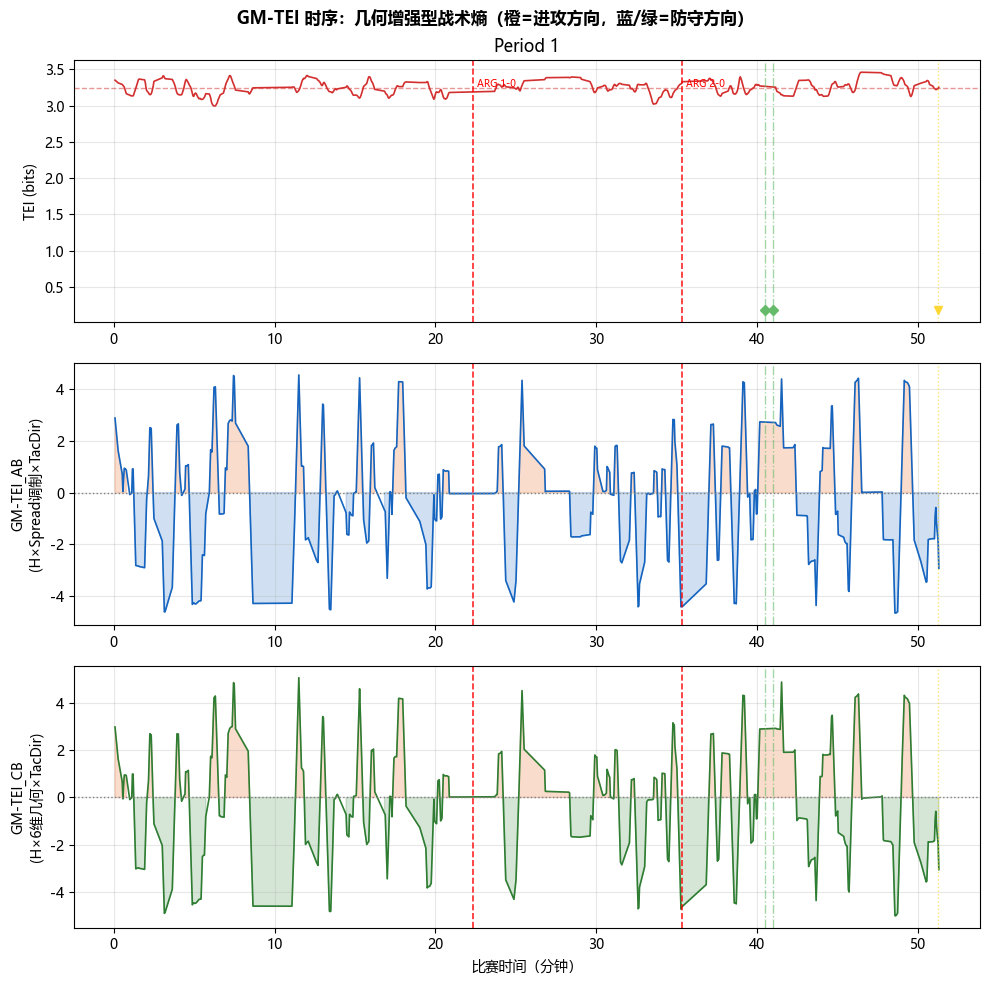

TacDir: 进攻窗口=319 (48.2%),  防守窗口=343 (51.8%)
GM-TEI_AB 均值=-0.179   GM-TEI_CB 均值=-0.179
已保存 gm_tei_timeseries_10517.png


In [7]:
# 加载窗口级数据（含 gm_tei_ab / gm_tei_cb / tac_dir / 几何特征）
b1_path = (base_path / 'Step3_Probabilistic_Identification'
           / '3.2_Probabilistic_Model' / 'Test' / 'b1_window_distributions.parquet')
b1_win = pd.read_parquet(b1_path).sort_values('center_fid').reset_index(drop=True)

# 合并 time_sec + period_id（df_pd 已在 Cell 12 构建）
ts_meta = df_pd[['frame_id', 'time_sec', 'period_id']].drop_duplicates('frame_id')
b1_win  = b1_win.merge(ts_meta.rename(columns={'frame_id': 'center_fid'}),
                        on='center_fid', how='left').dropna(subset=['time_sec'])
b1_win['period_id'] = b1_win['period_id'].astype(int)

periods_b1 = sorted(b1_win['period_id'].unique())
WROLL = 10
fig, axes = plt.subplots(3, len(periods_b1),
                          figsize=(max(10, 6*len(periods_b1)), 10),
                          sharey='row', squeeze=False)
for col, pid in enumerate(periods_b1):
    sub = b1_win[b1_win['period_id']==pid].sort_values('time_sec').reset_index(drop=True)
    t    = sub['time_sec'] / 60
    tei_s = sub['tei'].rolling(WROLL, center=True, min_periods=1).mean()
    ab_s  = sub['gm_tei_ab'].rolling(WROLL, center=True, min_periods=1).mean()
    cb_s  = sub['gm_tei_cb'].rolling(WROLL, center=True, min_periods=1).mean()
    axes[0,col].plot(t, tei_s, color='#D32F2F', lw=1.2, label='TEI')
    axes[0,col].axhline(sub['tei'].mean(), color='#D32F2F', ls='--', lw=1, alpha=0.5)
    axes[0,col].set_title(f'Period {pid}'); axes[0,col].grid(True, alpha=0.3)
    axes[1,col].plot(t, ab_s, color='#1565C0', lw=1.2, label='GM-TEI_AB')
    axes[1,col].axhline(0, color='gray', ls=':', lw=1)
    axes[1,col].fill_between(t, ab_s, 0, where=ab_s>=0, alpha=0.2, color='#E65100')
    axes[1,col].fill_between(t, ab_s, 0, where=ab_s<0,  alpha=0.2, color='#1565C0')
    axes[1,col].grid(True, alpha=0.3)
    axes[2,col].plot(t, cb_s, color='#2E7D32', lw=1.2, label='GM-TEI_CB')
    axes[2,col].axhline(0, color='gray', ls=':', lw=1)
    axes[2,col].fill_between(t, cb_s, 0, where=cb_s>=0, alpha=0.2, color='#E65100')
    axes[2,col].fill_between(t, cb_s, 0, where=cb_s<0,  alpha=0.2, color='#2E7D32')
    axes[2,col].set_xlabel('比赛时间（分钟）'); axes[2,col].grid(True, alpha=0.3)
    # 三行共用事件标注
    t_min_p = sub['time_sec'].min() / 60
    t_max_p = sub['time_sec'].max() / 60
    for row_ax in range(3):
        ax = axes[row_ax, col]
        for lbl, (gpid, gt) in GOALS.items():
            if gpid == pid and t_min_p <= gt/60 <= t_max_p:
                ax.axvline(gt/60, color='red', lw=1.2, ls='--', alpha=0.85)
                if row_ax == 0:
                    ax.text(gt/60+0.2, ax.get_ylim()[1]*0.97 if ax.get_ylim()[1]>0 else 1,
                            lbl.split('(')[0].strip(), fontsize=7, color='red', va='top')
        for yc in YELLOW_CARDS:
            if yc['period'] == pid and t_min_p <= yc['ts']/60 <= t_max_p:
                ax.axvline(yc['ts']/60, color='#FDD835', lw=1, ls=':', alpha=0.7)
                if row_ax == 0:
                    ax.plot(yc['ts']/60, ax.get_ylim()[1]*0.05 if ax.get_ylim()[1]>0 else 0,
                            marker='v', color='#FDD835', markersize=6, zorder=5)
        for sb in SUBSTITUTIONS:
            if sb['period'] == pid and t_min_p <= sb['ts']/60 <= t_max_p:
                ax.axvline(sb['ts']/60, color='#66BB6A', lw=1, ls='-.', alpha=0.6)
                if row_ax == 0:
                    ax.plot(sb['ts']/60, ax.get_ylim()[1]*0.05 if ax.get_ylim()[1]>0 else 0,
                            marker='D', color='#66BB6A', markersize=5, zorder=5)
axes[0,0].set_ylabel('TEI (bits)')
axes[1,0].set_ylabel('GM-TEI_AB\n(H×Spread调制×TacDir)')
axes[2,0].set_ylabel('GM-TEI_CB\n(H×6维几何×TacDir)')
fig.suptitle('GM-TEI 时序：几何增强型战术熵（橙=进攻方向，蓝/绿=防守方向）',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / 'gm_tei_timeseries_10517.png', dpi=150, bbox_inches='tight')
plt.show()
atk  = (b1_win['tac_dir'] > 0).sum(); def_ = (b1_win['tac_dir'] < 0).sum()
print(f'TacDir: 进攻窗口={atk} ({atk/len(b1_win):.1%}),  防守窗口={def_} ({def_/len(b1_win):.1%})')
print(f'GM-TEI_AB 均值={b1_win["gm_tei_ab"].mean():.3f}   GM-TEI_CB 均值={b1_win["gm_tei_cb"].mean():.3f}')
print('已保存 gm_tei_timeseries_10517.png')


## 7. TEI 按战术情境分组统计

C:\Users\11254\AppData\Local\Temp\ipykernel_32736\1673495498.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups_macro.values(), labels=groups_macro.keys(), patch_artist=True,
C:\Users\11254\AppData\Local\Temp\ipykernel_32736\1673495498.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(groups_fine.values(), labels=groups_fine.keys(), patch_artist=True,


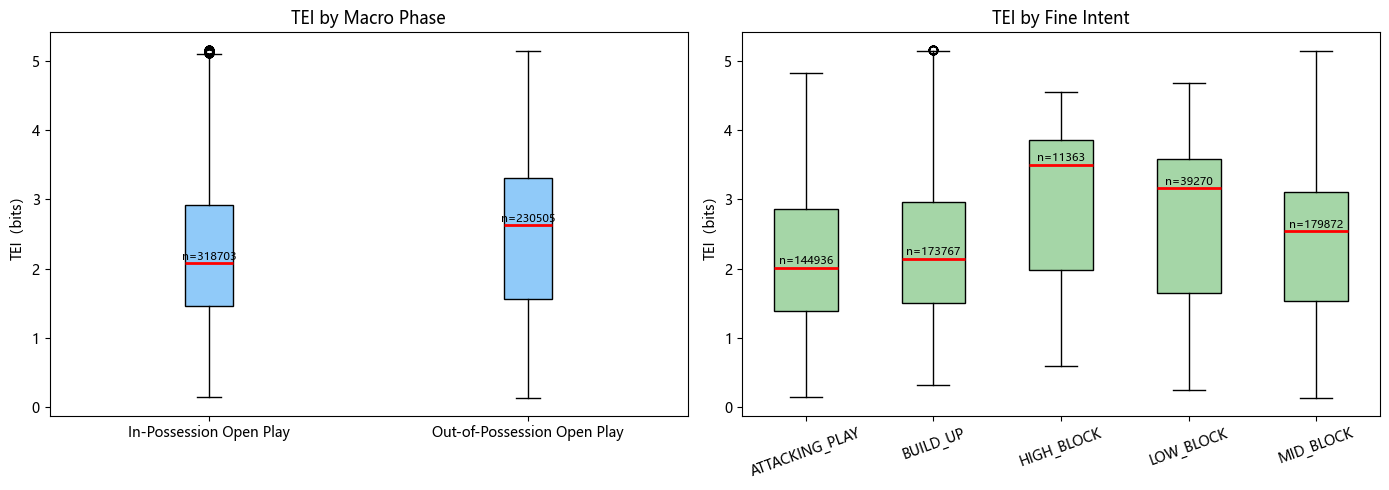

Mann-Whitney U (In-Possession Open Play vs Out-of-Possession Open Play): U=30912163848, p=0.0000
结论: 显著差异 (p<0.05)


In [8]:
df_ctx = df_pd.dropna(subset=["macro_phase", "fine_intent", "tei"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

groups_macro = {k: v["tei"].values for k, v in df_ctx.groupby("macro_phase")}
axes[0].boxplot(groups_macro.values(), labels=groups_macro.keys(), patch_artist=True,
                boxprops=dict(facecolor="#90CAF9"), medianprops=dict(color="red", lw=2))
axes[0].set_title("TEI by Macro Phase")
axes[0].set_ylabel("TEI（bits）")
for i, (k, v) in enumerate(groups_macro.items()):
    axes[0].text(i+1, np.median(v)+0.05, f"n={len(v)}", ha="center", fontsize=8)

groups_fine = {k: v["tei"].values for k, v in df_ctx.groupby("fine_intent")}
axes[1].boxplot(groups_fine.values(), labels=groups_fine.keys(), patch_artist=True,
                boxprops=dict(facecolor="#A5D6A7"), medianprops=dict(color="red", lw=2))
axes[1].set_title("TEI by Fine Intent")
axes[1].set_ylabel("TEI（bits）")
axes[1].tick_params(axis='x', rotation=20)
for i, (k, v) in enumerate(groups_fine.items()):
    axes[1].text(i+1, np.median(v)+0.05, f"n={len(v)}", ha="center", fontsize=8)

plt.tight_layout()
fig.savefig(out_dir / "tei_by_context_10517.png", dpi=150, bbox_inches="tight")
plt.show()

keys = list(groups_macro.keys())
if len(keys) >= 2:
    stat, p = mannwhitneyu(groups_macro[keys[0]], groups_macro[keys[1]], alternative='two-sided')
    print(f"Mann-Whitney U ({keys[0]} vs {keys[1]}): U={stat:.0f}, p={p:.4f}")
    print("结论:", "显著差异 (p<0.05)" if p < 0.05 else "无显著差异")

## 7.5 贝叶斯置信区间宽度按战术情境分析

- CI 宽度 = 1.96×sqrt(probvar_k均值)，来自 Dirichlet 后验方差
- 若某战术情境下 CI 宽度显著更高 → 该情境阵型更难确定（战术多样或过渡中）

C:\Users\11254\AppData\Local\Temp\ipykernel_32736\3544115450.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups_macro.values(), labels=groups_macro.keys(), patch_artist=True,
C:\Users\11254\AppData\Local\Temp\ipykernel_32736\3544115450.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(groups_fine.values(), labels=groups_fine.keys(), patch_artist=True,


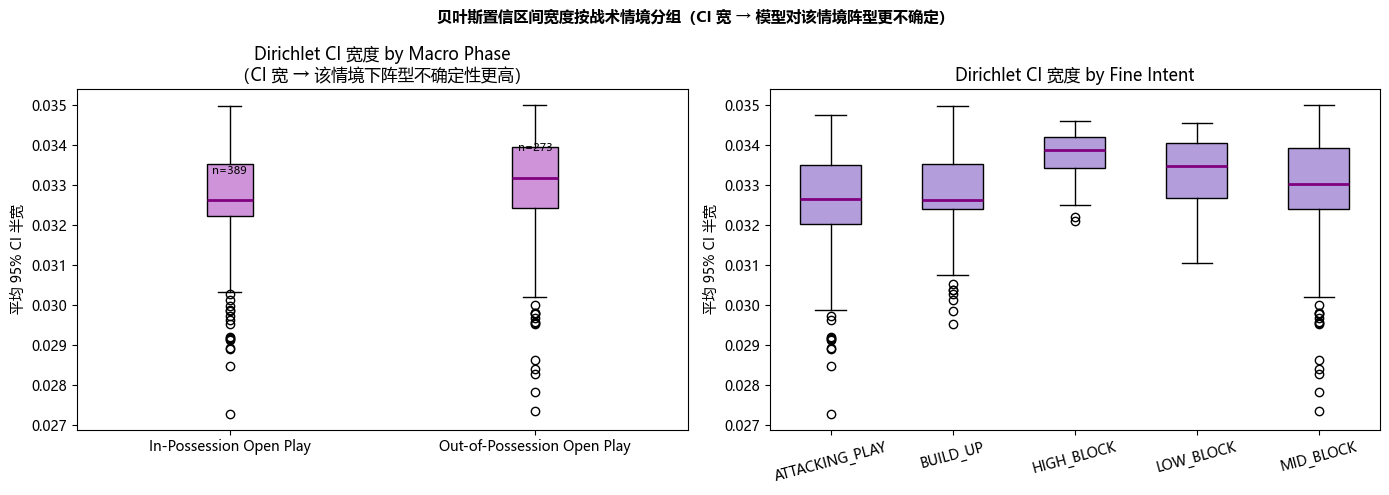

全局 CI 半宽均值: 0.03279
Mann-Whitney U (In-Possession Open Play vs Out-of-Possession Open Play): U=43635, p=0.0001
已保存 ci_by_context_10517.png


In [9]:
probvar_cols = [c for c in b1_win.columns if c.startswith('probvar_')]
if not probvar_cols:
    print('[WARN] 未找到 probvar_* 列，请确认已用贝叶斯方案B重跑 3.2.4')
else:
    b1_win['mean_ci_half'] = (
        b1_win[probvar_cols].clip(lower=0).pow(0.5).mean(axis=1) * 1.96
    )
    ctx_meta = df_pd[['frame_id','macro_phase','fine_intent']].drop_duplicates('frame_id')
    b1_ctx = b1_win.merge(ctx_meta.rename(columns={'frame_id':'center_fid'}),
                           on='center_fid', how='left').dropna(subset=['macro_phase','mean_ci_half'])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    groups_macro = {k: v['mean_ci_half'].values for k, v in b1_ctx.groupby('macro_phase')}
    axes[0].boxplot(groups_macro.values(), labels=groups_macro.keys(), patch_artist=True,
                    boxprops=dict(facecolor='#CE93D8'), medianprops=dict(color='purple', lw=2))
    axes[0].set_title('Dirichlet CI 宽度 by Macro Phase\n（CI 宽 → 该情境下阵型不确定性更高）')
    axes[0].set_ylabel('平均 95% CI 半宽')
    for i, (k, v) in enumerate(groups_macro.items()):
        axes[0].text(i+1, float(np.median(v))*1.02, f'n={len(v)}', ha='center', fontsize=8)
    groups_fine = {k: v['mean_ci_half'].values for k, v in b1_ctx.groupby('fine_intent')}
    axes[1].boxplot(groups_fine.values(), labels=groups_fine.keys(), patch_artist=True,
                    boxprops=dict(facecolor='#B39DDB'), medianprops=dict(color='purple', lw=2))
    axes[1].set_title('Dirichlet CI 宽度 by Fine Intent')
    axes[1].set_ylabel('平均 95% CI 半宽')
    axes[1].tick_params(axis='x', rotation=15)
    plt.suptitle('贝叶斯置信区间宽度按战术情境分组（CI 宽 → 模型对该情境阵型更不确定）',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(out_dir / 'ci_by_context_10517.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'全局 CI 半宽均值: {b1_ctx["mean_ci_half"].mean():.5f}')
    keys = list(groups_macro.keys())
    if len(keys) >= 2:
        from scipy.stats import mannwhitneyu
        stat, p = mannwhitneyu(groups_macro[keys[0]], groups_macro[keys[1]], alternative='two-sided')
        print(f'Mann-Whitney U ({keys[0]} vs {keys[1]}): U={stat:.0f}, p={p:.4f}')
    print('已保存 ci_by_context_10517.png')


## 7.6 TEI 置信带时序图（贝叶斯不确定性）

- 数据来源：`b1_window_distributions.parquet` 的 `tei` + `probvar_*` 列
- CI 半宽 = 1.96 × sqrt(mean(probvar_*))，来自 Dirichlet 后验方差
- **CI 窄的区段 ⇒ TEI 更可信**；阴影区宽度 = 模型在该窗口的不确定性大小


C:\Users\11254\AppData\Local\Temp\ipykernel_32736\859238249.py:83: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\11254\AppData\Local\Temp\ipykernel_32736\859238249.py:85: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Microsoft YaHei.
  fig.savefig(out_dir_a / 'tei_confidence_band_10517.png', dpi=150, bbox_inches='tight')
e:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH\MORPHenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


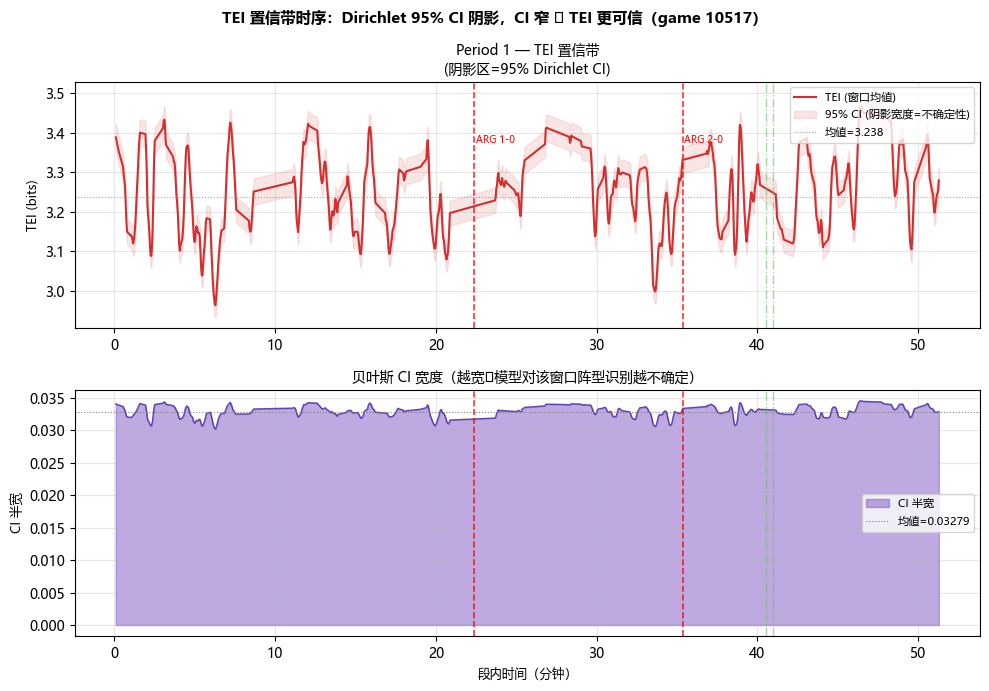

CI 半宽: 均値=0.03279, 最小=0.02727, 最大=0.03500
IQR=[0.03232, 0.03371]
已保存 tei_confidence_band_10517.png


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    _ = b1_win.shape
except NameError:
    b1_path_ci = (base_path / 'Step3_Probabilistic_Identification'
                  / '3.2_Probabilistic_Model' / 'Test' / 'b1_window_distributions.parquet')
    b1_win = pd.read_parquet(b1_path_ci)
    ts_meta_ci = df_pd[['frame_id','time_sec','period_id']].drop_duplicates('frame_id')
    b1_win = b1_win.merge(ts_meta_ci.rename(columns={'frame_id':'center_fid'}),
                           on='center_fid', how='left').dropna(subset=['time_sec'])
    b1_win['period_id'] = b1_win['period_id'].astype(int)

pv_cols = [c for c in b1_win.columns if c.startswith('probvar_')]
if not pv_cols:
    print('[SKIP] 缺少 probvar_* 列，跳过 TEI 置信带绘制')
else:
    b1_cb = b1_win.copy()
    b1_cb['ci_half'] = b1_cb[pv_cols].clip(lower=0).pow(0.5).mean(axis=1) * 1.96
    b1_cb['tei_upper'] = b1_cb['tei'] + b1_cb['ci_half']
    b1_cb['tei_lower'] = (b1_cb['tei'] - b1_cb['ci_half']).clip(lower=0)

    periods_cb = sorted(b1_cb['period_id'].unique())
    WROLL_CB = 8
    fig, axes = plt.subplots(2, len(periods_cb),
                              figsize=(max(10, 7*len(periods_cb)), 7),
                              squeeze=False)

    for col, pid in enumerate(periods_cb):
        sub = b1_cb[b1_cb['period_id']==pid].sort_values('time_sec').reset_index(drop=True)
        t = sub['time_sec'] / 60
        tei_s   = sub['tei'].rolling(WROLL_CB, center=True, min_periods=1).mean()
        upper_s = sub['tei_upper'].rolling(WROLL_CB, center=True, min_periods=1).mean()
        lower_s = sub['tei_lower'].rolling(WROLL_CB, center=True, min_periods=1).mean()
        ci_s    = sub['ci_half'].rolling(WROLL_CB, center=True, min_periods=1).mean()

        # 上图：TEI + CI 阴影带
        ax0 = axes[0, col]
        ax0.plot(t, tei_s, lw=1.5, color='#D32F2F', label='TEI (窗口均値)')
        ax0.fill_between(t, lower_s, upper_s,
                          alpha=0.25, color='#EF9A9A',
                          label='95% CI (阴影宽度=不确定性)')
        ax0.axhline(tei_s.mean(), color='gray', lw=0.8, ls=':', alpha=0.7,
                    label=f'均値={tei_s.mean():.3f}')
        ax0.set_ylabel('TEI (bits)', fontsize=9)
        ax0.set_title(f'Period {pid} — TEI 置信带\n(阴影区=95% Dirichlet CI)', fontsize=10)
        ax0.legend(fontsize=8, loc='upper right')
        ax0.grid(True, alpha=0.3)

        # 下图：CI 宽度时序
        ax1 = axes[1, col]
        ax1.fill_between(t, 0, ci_s, alpha=0.5, color='#7E57C2', label='CI 半宽')
        ax1.plot(t, ci_s, lw=1, color='#4527A0', alpha=0.8)
        ax1.axhline(ci_s.mean(), color='gray', lw=0.8, ls=':',
                    label=f'均値={ci_s.mean():.5f}')

        t_min_p = t.min(); t_max_p = t.max()
        try:
            for lbl, (gpid, gt) in GOALS.items():
                if gpid==pid and t_min_p <= gt/60 <= t_max_p:
                    for ax in [ax0, ax1]:
                        ax.axvline(gt/60, color='red', lw=1.2, ls='--', alpha=0.8)
                    ax0.text(gt/60+0.1, upper_s.max()*0.97,
                             lbl.split('(')[0].strip(), fontsize=7, color='red', va='top')
            for sb in SUBSTITUTIONS:
                if sb['period']==pid and t_min_p <= sb['ts']/60 <= t_max_p:
                    for ax in [ax0, ax1]:
                        ax.axvline(sb['ts']/60, color='#66BB6A', lw=1, ls='-.', alpha=0.6)
        except NameError:
            pass

        ax1.set_xlabel('段内时间（分钟）', fontsize=9)
        ax1.set_ylabel('CI 半宽', fontsize=9)
        ax1.set_title('贝叶斯 CI 宽度（越宽⇒模型对该窗口阵型识别越不确定）', fontsize=10)
        ax1.legend(fontsize=8)
        ax1.grid(True, alpha=0.3)

    plt.suptitle('TEI 置信带时序：Dirichlet 95% CI 阴影，CI 窄 ⇒ TEI 更可信（game 10517）',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    out_dir_a = base_path / 'data' / 'morph_test' / 'bgnn_analysis'
    fig.savefig(out_dir_a / 'tei_confidence_band_10517.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'CI 半宽: 均値={b1_cb["ci_half"].mean():.5f}, '
          f'最小={b1_cb["ci_half"].min():.5f}, 最大={b1_cb["ci_half"].max():.5f}')
    ci_q25, ci_q75 = b1_cb['ci_half'].quantile([0.25, 0.75])
    print(f'IQR=[{ci_q25:.5f}, {ci_q75:.5f}]')
    print('已保存 tei_confidence_band_10517.png')


## 7.7 MC Dropout 帧级认知不确定性时序

- 数据来源：`b1_frame_epistemic.npy`（帧级认知不确定性 = MC Dropout 最大分量方差）
- 与帧级 TEI 双轴叠加：验证 epistemic 高峰是否对应 TEI 升高
- 标注高认知不确定性时刻（模型处于决策边界），输出 Spearman 相关性检验


epistemic: n=49928, 均値=0.016306, 最大=0.067324, 阈値=0.031279


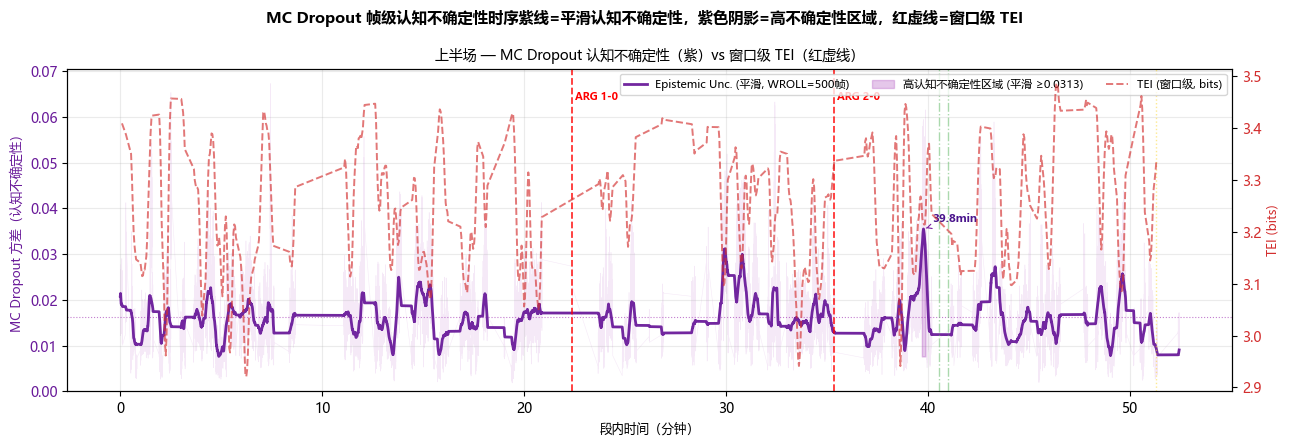

已保存 mc_dropout_epistemic_10517.png
Spearman r=-0.1961 (p=0.000e+00)  |  Pearson r=-0.0919 (p=3.617e-94)
注：epistemic=模型决策边界不确定性，TEI=半场局内部熵，弱相关属正常


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ep_path = (base_path / 'Step3_Probabilistic_Identification'
           / '3.2_Probabilistic_Model' / 'Test' / 'b1_frame_epistemic.npy')
if not ep_path.exists():
    print(f'[SKIP] {ep_path} 不存在')
else:
    ep_vals = np.load(ep_path)  # shape (N_graphs,), 帧级 MC Dropout 方差

    try:
        fids = [int(f) for f in all_frame_ids]
    except NameError:
        print('[WARN] all_frame_ids 未定义，请先运行 Cell 4')
        fids = None

    if fids is not None and len(fids) == len(ep_vals):
        ep_df = pd.DataFrame({'frame_id': fids, 'epistemic': ep_vals.tolist()})
        ep_df = ep_df.drop_duplicates('frame_id')

        # merge time_sec + period_id + frame_level tei
        try:
            ts_ep = df_pd[['frame_id','time_sec','period_id','tei']].drop_duplicates('frame_id')
        except NameError:
            import polars as _pl
            _tmp = _pl.read_parquet(out_dir / 'tei_timeseries_10517.parquet').to_pandas()
            ts_ep = _tmp[['frame_id','time_sec','period_id','tei']].drop_duplicates('frame_id')

        ep_df = ep_df.merge(ts_ep, on='frame_id', how='left').dropna(subset=['time_sec','period_id'])
        ep_df['period_id'] = ep_df['period_id'].astype(int)
        ep_df = ep_df.sort_values('time_sec').reset_index(drop=True)

        # 平滑参数：500 帧 ≈ 20s@25fps，充分去噪声
        WROLL_EP = 500
        EP_HIGH = ep_df['epistemic'].mean() + 2 * ep_df['epistemic'].std()

        print(f'epistemic: n={len(ep_df)}, 均値={ep_df["epistemic"].mean():.6f}, '
              f'最大={ep_df["epistemic"].max():.6f}, 阈値={EP_HIGH:.6f}')

        # 窗口级 TEI（来自 b1_win，662个点，远比帧级平滑）
        try:
            _ = b1_win.shape
            win_tei = b1_win[['time_sec','tei']].dropna().sort_values('time_sec')
        except NameError:
            win_tei = None

        periods_ep = sorted(ep_df['period_id'].unique())
        fig, axes = plt.subplots(len(periods_ep), 1,
                                  figsize=(13, 4.5*len(periods_ep)), squeeze=False)

        for row_i, pid in enumerate(periods_ep):
            ax = axes[row_i, 0]
            sub = ep_df[ep_df['period_id']==pid].sort_values('time_sec').reset_index(drop=True)
            t = sub['time_sec'] / 60

            # 平滑 epistemic（主曲线）
            ep_raw = sub['epistemic'].values
            ep_s   = sub['epistemic'].rolling(WROLL_EP, center=True, min_periods=1).mean()

            # 极饱和线：超级轻叠的原始信号（仅供参考）
            ax.plot(t, ep_raw, lw=0.4, color='#CE93D8', alpha=0.2, zorder=1)
            # 主平滑曲线
            ax.plot(t, ep_s, lw=2.0, color='#6A1B9A', alpha=0.95, zorder=3,
                    label='Epistemic Unc. (平滑, WROLL=500帧)')
            # 高认知不确定性区域（平滑信号 ≥ 阈値）
            ax.fill_between(t, ep_s, ep_s.min(),
                             where=(ep_s >= EP_HIGH), alpha=0.3, color='#AB47BC', zorder=2,
                             label=f'高认知不确定性区域 (平滑 ≥{EP_HIGH:.4f})')
            ax.axhline(ep_df['epistemic'].mean(), color='#9C27B0', lw=0.8, ls=':', alpha=0.6)

            ax.set_ylabel('MC Dropout 方差（认知不确定性）',
                           color='#6A1B9A', fontsize=9)
            ax.tick_params(axis='y', labelcolor='#6A1B9A')
            ax.set_ylim(bottom=0)

            # 右轴：窗口级 TEI（来自 b1_win，已平滑）
            ax2 = ax.twinx()
            if win_tei is not None:
                # 必须限制在当前 period 时间范围内
                t_min_p = sub['time_sec'].min(); t_max_p = sub['time_sec'].max()
                wt_sub = win_tei[(win_tei['time_sec'] >= t_min_p) &
                                  (win_tei['time_sec'] <= t_max_p)]
                if len(wt_sub) > 0:
                    wt_s = wt_sub['tei'].rolling(5, center=True, min_periods=1).mean()
                    ax2.plot(wt_sub['time_sec']/60, wt_s, lw=1.4, color='#D32F2F',
                              alpha=0.65, ls='--', zorder=3, label='TEI (窗口级, bits)')
            ax2.set_ylabel('TEI (bits)', color='#D32F2F', fontsize=9)
            ax2.tick_params(axis='y', labelcolor='#D32F2F')

            # 标注 Top-3 平滑帧级认知不确定性尖唃（帧内最高点，时间间隔 > 3min）
            ep_s_vals = ep_s.values
            peak_times, peak_vals, last_t = [], [], -999
            for idx in np.argsort(-ep_s_vals):
                pt = t.iloc[idx] if hasattr(t, 'iloc') else t[idx]
                pv = ep_s_vals[idx]
                if pv < EP_HIGH: break
                if pt - last_t > 3.0:   # 至少间隔 3 分钟
                    peak_times.append(pt)
                    peak_vals.append(pv)
                    last_t = pt
                if len(peak_times) >= 3:
                    break
            for pt, pv in zip(peak_times, peak_vals):
                ax.annotate(f'{pt:.1f}min',
                             xy=(pt, pv), xytext=(6, 5),
                             textcoords='offset points',
                             fontsize=8, color='#4A148C', fontweight='bold',
                             arrowprops=dict(arrowstyle='->', color='#7B1FA2', lw=0.8))

            # 事件标注
            t_min_p_m = t.min(); t_max_p_m = t.max()
            try:
                for lbl, (gpid, gt) in GOALS.items():
                    if gpid==pid and t_min_p_m <= gt/60 <= t_max_p_m:
                        ax.axvline(gt/60, color='red', lw=1.3, ls='--', alpha=0.8, zorder=4)
                        ax.text(gt/60+0.15, ax.get_ylim()[1]*0.93,
                                lbl.split('(')[0].strip(), fontsize=7.5,
                                color='red', va='top', fontweight='bold')
                for sb in SUBSTITUTIONS:
                    if sb['period']==pid and t_min_p_m <= sb['ts']/60 <= t_max_p_m:
                        ax.axvline(sb['ts']/60, color='#66BB6A', lw=1, ls='-.', alpha=0.55, zorder=4)
                for yc in YELLOW_CARDS:
                    if yc['period']==pid and t_min_p_m <= yc['ts']/60 <= t_max_p_m:
                        ax.axvline(yc['ts']/60, color='#FDD835', lw=1, ls=':', alpha=0.55, zorder=4)
            except NameError:
                pass

            ax.set_xlabel('段内时间（分钟）', fontsize=9)
            ax.set_title(f'{PERIOD_LABELS.get(pid, f"Period {pid}")} '
                          '— MC Dropout 认知不确定性（紫）vs 窗口级 TEI（红虚线）',
                          fontsize=10)
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(lines1+lines2, labels1+labels2,
                       fontsize=8, loc='upper right', ncol=3)
            ax.grid(True, alpha=0.25)

        plt.suptitle('MC Dropout 帧级认知不确定性时序'
                     '紫线=平滑认知不确定性，紫色阴影=高不确定性区域，红虚线=窗口级 TEI',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        out_dir_b = base_path / 'data' / 'morph_test' / 'bgnn_analysis'
        fig.savefig(out_dir_b / 'mc_dropout_epistemic_10517.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('已保存 mc_dropout_epistemic_10517.png')

        from scipy.stats import spearmanr, pearsonr
        r_sp, p_sp = spearmanr(ep_df['epistemic'], ep_df['tei'])
        r_pe, p_pe = pearsonr(ep_df['epistemic'], ep_df['tei'])
        print(f'Spearman r={r_sp:.4f} (p={p_sp:.3e})  |  Pearson r={r_pe:.4f} (p={p_pe:.3e})')
        print('注：epistemic=模型决策边界不确定性，TEI=半场局内部熵，弱相关属正常')
    else:
        print(f'[WARN] ep_vals 长度({len(ep_vals)}) 与 all_frame_ids 不匹配')


## 8. B-GNN Top-1 vs EFPI 一致性分析

B-GNN vs EFPI 一致率: 89.8%
不一致帧 TEI 均值=3.462 | 一致帧 TEI 均值=2.197
Mann-Whitney U (不一致>一致): p=0.0000


C:\Users\11254\AppData\Local\Temp\ipykernel_32736\50476776.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([tei_agree, tei_disagree], labels=["一致", "不一致"], patch_artist=True,


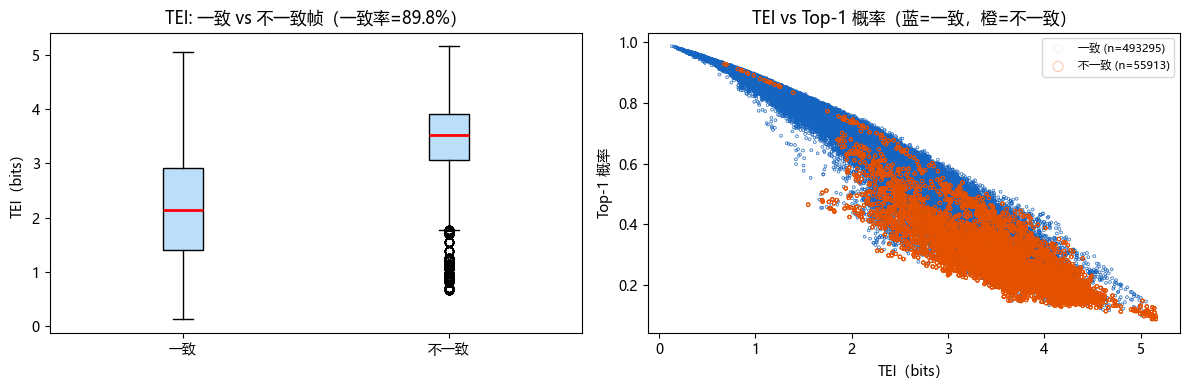

In [17]:
df_cmp = df_pd.dropna(subset=["top1_formation", "efpi_formation", "tei"])
agree = (df_cmp["top1_formation"] == df_cmp["efpi_formation"])
agree_rate = agree.mean()
print(f"B-GNN vs EFPI 一致率: {agree_rate*100:.1f}%")

tei_agree    = df_cmp[agree]["tei"].values
tei_disagree = df_cmp[~agree]["tei"].values
stat, p = mannwhitneyu(tei_disagree, tei_agree, alternative='greater')
print(f"不一致帧 TEI 均值={tei_disagree.mean():.3f} | 一致帧 TEI 均值={tei_agree.mean():.3f}")
print(f"Mann-Whitney U (不一致>一致): p={p:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([tei_agree, tei_disagree], labels=["一致", "不一致"], patch_artist=True,
                boxprops=dict(facecolor="#BBDEFB"), medianprops=dict(color="red", lw=2))
axes[0].set_title(f"TEI: 一致 vs 不一致帧（一致率={agree_rate*100:.1f}%）")
axes[0].set_ylabel("TEI（bits）")

# 全量绘制，空心点（facecolors='none'）避免遮挡，先画多数类再画少数类
tei_vals  = df_cmp['tei'].values
prob_vals = df_cmp['top1_prob'].values

axes[1].scatter(tei_vals[agree.values], prob_vals[agree.values],
                facecolors='none', edgecolors='#1565C0',
                alpha=0.15, s=4, linewidths=0.4,
                label=f'一致 (n={agree.sum()})', rasterized=True)
axes[1].scatter(tei_vals[~agree.values], prob_vals[~agree.values],
                facecolors='none', edgecolors='#E65100',
                alpha=0.4, s=6, linewidths=0.6,
                label=f'不一致 (n={(~agree).sum()})', rasterized=True)
axes[1].set_xlabel("TEI（bits）")
axes[1].set_ylabel("Top-1 概率")
axes[1].set_title("TEI vs Top-1 概率（蓝=一致，橙=不一致）")
axes[1].legend(fontsize=8, markerscale=3)
plt.tight_layout()
fig.savefig(out_dir / "bgnn_vs_efpi_10517.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. 高 TEI 帧事件研究法（Event Study）

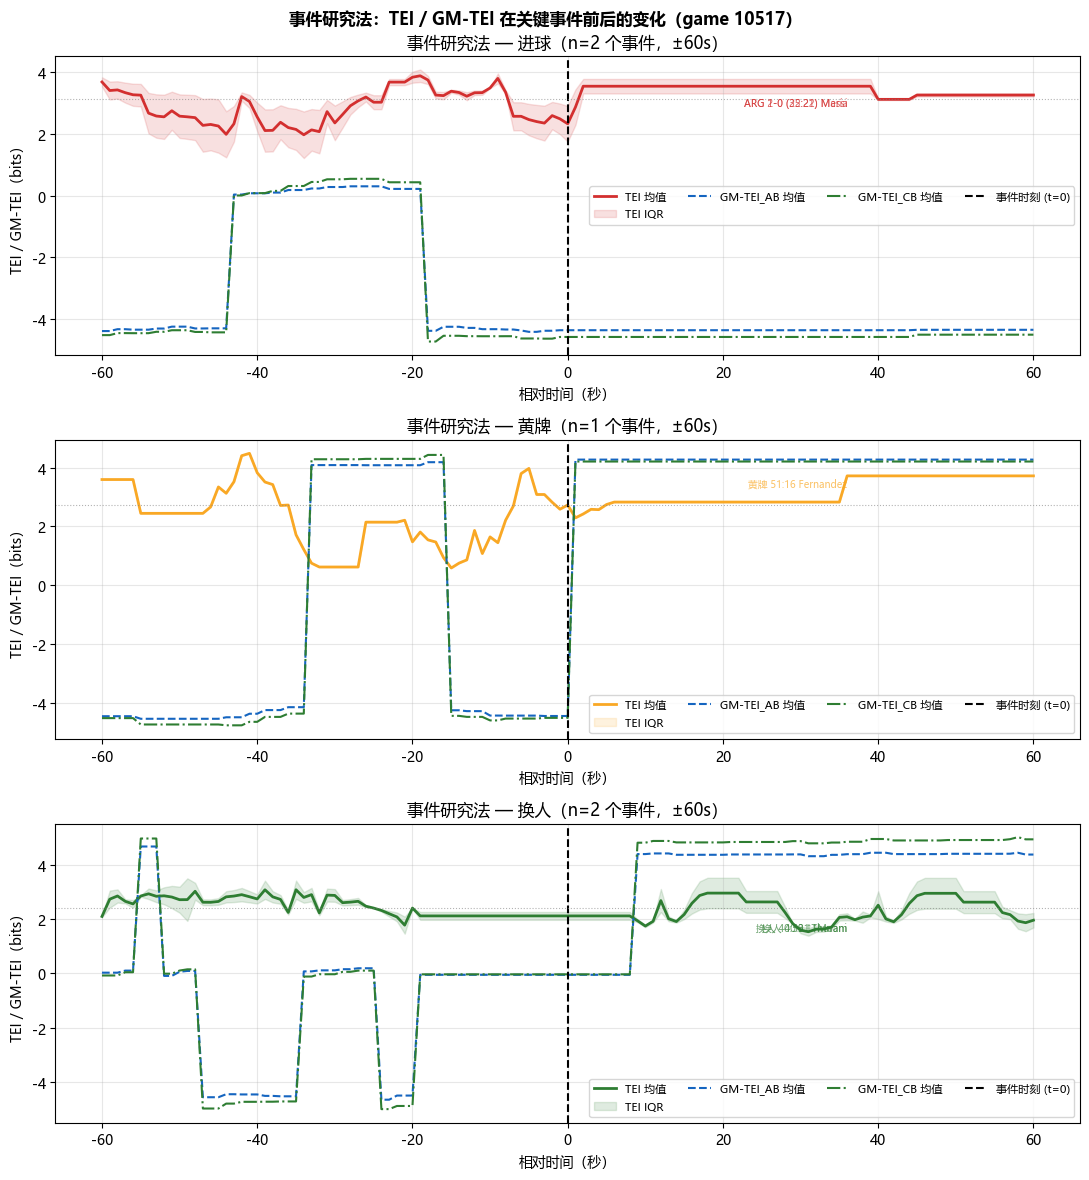

已保存 event_study_tei_10517.png


In [18]:
TEI_HIGH_THRESHOLD = 4.0  # bits
WINDOW_SEC = 60           # 事件前后各 60 秒

# ── 加载帧级 TEI ──────────────────────────────────────────────────────────
try:
    df_pd_ev = result_df.to_pandas().dropna(subset=["time_sec","tei","period_id"])
except NameError:
    import polars as _pl
    df_pd_ev = _pl.read_parquet(out_dir/"tei_timeseries_10517.parquet").to_pandas().dropna(subset=["time_sec","tei","period_id"])
    print("[INFO] 从 parquet 加载")
df_pd_ev = df_pd_ev.drop_duplicates("frame_id").sort_values("time_sec").reset_index(drop=True)
df_pd_ev["period_id"] = df_pd_ev["period_id"].astype(int)
covered_periods = set(df_pd_ev["period_id"].unique())

# ── 加载窗口级 GM-TEI（b1_win 可能已在 Cell 14 定义，否则重新加载）────────
try:
    _ = b1_win.shape
except NameError:
    b1_win = pd.read_parquet(base_path/'Step3_Probabilistic_Identification'
                             /'3.2_Probabilistic_Model'/'Test'/'b1_window_distributions.parquet')
    ts_meta = df_pd_ev[['frame_id','time_sec','period_id']].drop_duplicates('frame_id')
    b1_win = b1_win.merge(ts_meta.rename(columns={'frame_id':'center_fid'}),
                          on='center_fid', how='left').dropna(subset=['time_sec'])
    b1_win['period_id'] = b1_win['period_id'].astype(int)

# ── 构建全事件列表 {label: (period, time_sec, event_type)} ────────────────
all_events = {}
for lbl, (pid, ts) in GOALS.items():
    all_events[lbl] = (pid, ts, 'goal')
for yc in YELLOW_CARDS:
    surname = yc['player'].split()[-1] if yc['player'] else '?'
    lbl = f"黄牌 {yc['fmt']} {surname}"
    all_events[lbl] = (yc['period'], yc['ts'], 'yellow')
for sb in SUBSTITUTIONS:
    on_s = sb['on'].split()[-1] if sb['on'] else '?'
    lbl = f"换人 {sb['fmt']} ↑{on_s}"
    all_events[lbl] = (sb['period'], sb['ts'], 'sub')

offsets = np.arange(-WINDOW_SEC, WINDOW_SEC + 1)
event_colors = {'goal': '#D32F2F', 'yellow': '#F9A825', 'sub': '#2E7D32'}
event_markers = {'goal': '⚽', 'yellow': '🟨', 'sub': '🔄'}

# ── 按事件类型分组绘图 ────────────────────────────────────────────────────
event_groups = [
    ('goal',   '进球',   [k for k,v in all_events.items() if v[2]=='goal']),
    ('yellow', '黄牌',   [k for k,v in all_events.items() if v[2]=='yellow']),
    ('sub',    '换人',   [k for k,v in all_events.items() if v[2]=='sub']),
]
# 过滤掉当前数据不覆盖的事件
event_groups = [(etype, elbl, [k for k in keys
                               if all_events[k][0] in covered_periods
                               and df_pd_ev[df_pd_ev['period_id']==all_events[k][0]]['time_sec'].min()
                                  <= all_events[k][1]
                                  <= df_pd_ev[df_pd_ev['period_id']==all_events[k][0]]['time_sec'].max()])
                for etype, elbl, keys in event_groups]
event_groups = [(et, el, ks) for et, el, ks in event_groups if ks]

if not event_groups:
    print("当前数据范围内无有效事件，跳过绘图")
else:
    n_groups = len(event_groups)
    fig, axes = plt.subplots(n_groups, 1, figsize=(11, 4*n_groups), squeeze=False)

    for row_i, (etype, elbl, keys) in enumerate(event_groups):
        ax = axes[row_i, 0]
        color = event_colors[etype]

        # 收集 TEI / GM-TEI_AB / GM-TEI_CB 窗口曲线
        tei_mat, ab_mat, cb_mat = [], [], []
        for lbl in keys:
            pid, gt, _ = all_events[lbl]
            sub_f = df_pd_ev[df_pd_ev['period_id']==pid].sort_values('time_sec')
            t_arr = sub_f['time_sec'].values
            tei_arr = sub_f['tei'].values
            tei_row = [float(tei_arr[np.argmin(np.abs(t_arr-(gt+dt)))]) for dt in offsets]
            tei_mat.append(tei_row)
            # GM-TEI：从窗口数据中找最近窗口
            sub_w = b1_win[b1_win['period_id']==pid].sort_values('time_sec')
            tw = sub_w['time_sec'].values
            if len(tw) > 0:
                ab_row = [float(sub_w['gm_tei_ab'].values[np.argmin(np.abs(tw-(gt+dt)))])
                          for dt in offsets]
                cb_row = [float(sub_w['gm_tei_cb'].values[np.argmin(np.abs(tw-(gt+dt)))])
                          for dt in offsets]
                ab_mat.append(ab_row); cb_mat.append(cb_row)

        tei_arr2 = np.array(tei_mat)
        tei_mean = np.nanmean(tei_arr2, axis=0)
        tei_p25  = np.nanpercentile(tei_arr2, 25, axis=0)
        tei_p75  = np.nanpercentile(tei_arr2, 75, axis=0)

        ax.plot(offsets, tei_mean, lw=2, color=color, label='TEI 均值')
        ax.fill_between(offsets, tei_p25, tei_p75, alpha=0.15, color=color, label='TEI IQR')

        if ab_mat:
            ab_mean = np.nanmean(np.array(ab_mat), axis=0)
            cb_mean = np.nanmean(np.array(cb_mat), axis=0)
            ax.plot(offsets, ab_mean, lw=1.5, color='#1565C0', ls='--', label='GM-TEI_AB 均值')
            ax.plot(offsets, cb_mean, lw=1.5, color='#2E7D32', ls='-.', label='GM-TEI_CB 均值')

        ax.axvline(0, color='black', lw=1.5, ls='--', label='事件时刻 (t=0)')
        ax.axhline(np.nanmean(tei_mean), color='gray', lw=0.8, ls=':', alpha=0.6)
        ax.set_xlabel('相对时间（秒）'); ax.set_ylabel('TEI / GM-TEI（bits）')
        ax.set_title(f'事件研究法 — {elbl}（n={len(keys)} 个事件，±{WINDOW_SEC}s）')
        ax.legend(fontsize=8, ncol=4); ax.grid(True, alpha=0.3)
        # 标注各事件名
        for lbl in keys:
            _, gt, _ = all_events[lbl]
            ax.text(WINDOW_SEC*0.6, tei_mean[-1]*0.98,
                    lbl, fontsize=7, color=color, alpha=0.7, ha='right', va='top')

    fig.suptitle('事件研究法：TEI / GM-TEI 在关键事件前后的变化（game 10517）',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    fig.savefig(out_dir / 'event_study_tei_10517.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('已保存 event_study_tei_10517.png')


## 10. 时间相干性分析（JSD）

B-GNN 平均 JSD: 0.0054 bits
EFPI 标签变化率: 0.02%
绘图 period: [np.int64(1)]


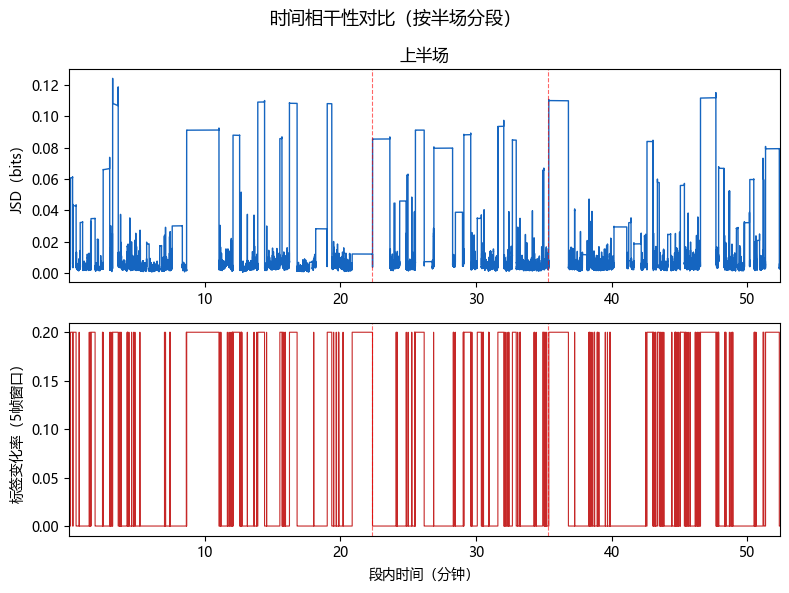

保存: jsd_timeseries_10517.parquet


In [19]:
def jsd(p, q, eps=1e-8):
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * np.log2(p / (m + eps) + eps), axis=-1)
    kl_qm = np.sum(q * np.log2(q / (m + eps) + eps), axis=-1)
    return 0.5 * kl_pm + 0.5 * kl_qm

sorted_idx = np.argsort(all_frame_ids)
sorted_probs = all_probs_np[sorted_idx]
sorted_fids  = np.array(all_frame_ids)[sorted_idx]

jsd_vals = jsd(sorted_probs[:-1], sorted_probs[1:])
jsd_fids = sorted_fids[1:]

# EFPI：用自带 period_id，再 merge time_sec
efpi_home_pl = efpi_pl.filter(pl.col("team_id") == HOME_TEAM_ID)
ts_df = result_df.select(["frame_id", "time_sec"]).to_pandas()

efpi_home_pd = efpi_home_pl.to_pandas().sort_values("frame_id").reset_index(drop=True)
efpi_home_pd = efpi_home_pd.merge(ts_df, on="frame_id", how="left")

print(f"B-GNN 平均 JSD: {jsd_vals.mean():.4f} bits")
efpi_change_rate = (efpi_home_pd["formation"].values[1:] != efpi_home_pd["formation"].values[:-1]).mean()
print(f"EFPI 标签变化率: {efpi_change_rate*100:.2f}%")

# B-GNN JSD：merge time_sec + period_id
df_jsd = pd.DataFrame({"frame_id": jsd_fids, "jsd": jsd_vals})
ts_pid_df = result_df.select(["frame_id", "time_sec", "period_id"]).to_pandas()
df_jsd_merged = df_jsd.merge(ts_pid_df, on="frame_id", how="left").dropna(subset=["time_sec", "period_id"])
df_jsd_merged["period_id"] = df_jsd_merged["period_id"].astype(int)

# EFPI：用自带 period_id
efpi_ts = efpi_home_pd.dropna(subset=["time_sec", "period_id"]).copy()
efpi_ts["period_id"] = efpi_ts["period_id"].astype(int)

periods = sorted(df_jsd_merged["period_id"].unique())
print(f"绘图 period: {periods}")

fig, axes = plt.subplots(2, len(periods), figsize=(max(8, 5*len(periods)), 6), sharey="row")
if len(periods) == 1:
    axes = axes.reshape(2, 1)

for col, pid in enumerate(periods):
    sub_jsd = df_jsd_merged[df_jsd_merged["period_id"] == pid].sort_values("time_sec")
    jsd_smooth = sub_jsd["jsd"].rolling(window=90, center=True, min_periods=1).mean()
    t_min = sub_jsd["time_sec"].min()
    t_max = sub_jsd["time_sec"].max()
    axes[0, col].plot(sub_jsd["time_sec"] / 60, jsd_smooth, lw=1, color="#1565C0")
    axes[0, col].set_xlim(t_min / 60, t_max / 60)
    axes[0, col].set_title(f"{PERIOD_LABELS.get(pid, f'P{pid}')}")
    for label, (gpid, gt) in GOALS.items():
        if gpid == pid and t_min <= gt <= t_max:
            axes[0, col].axvline(gt/60, color="red", lw=0.8, ls="--", alpha=0.6)

    sub_efpi = efpi_ts[efpi_ts["period_id"] == pid].sort_values("time_sec")
    if len(sub_efpi) > 1:
        efpi_chg = (sub_efpi["formation"].values[1:] != sub_efpi["formation"].values[:-1]).astype(float)
        # 窗口=5帧保留脉冲细节（原90帧过度平滑）
        efpi_smooth = pd.Series(efpi_chg).rolling(window=5, center=True, min_periods=1).mean()
        t_min_e = sub_efpi["time_sec"].min()
        t_max_e = sub_efpi["time_sec"].max()
        axes[1, col].plot(sub_efpi["time_sec"].values[1:] / 60, efpi_smooth, lw=0.8, color="#C62828")
        axes[1, col].set_xlim(t_min_e / 60, t_max_e / 60)
        for label, (gpid, gt) in GOALS.items():
            if gpid == pid and t_min_e <= gt <= t_max_e:
                axes[1, col].axvline(gt/60, color="red", lw=0.8, ls="--", alpha=0.6)
    axes[1, col].set_xlabel("段内时间（分钟）")

axes[0, 0].set_ylabel("JSD（bits）")
axes[1, 0].set_ylabel("标签变化率（5帧窗口）")
fig.suptitle("时间相干性对比（按半场分段）", fontsize=13)
plt.tight_layout()
fig.savefig(out_dir / "jsd_temporal_coherence_10517.png", dpi=150, bbox_inches="tight")
plt.show()

pl.DataFrame({"frame_id": [int(f) for f in jsd_fids], "jsd": jsd_vals.tolist()}).write_parquet(
    out_dir / "jsd_timeseries_10517.parquet"
)
print("保存: jsd_timeseries_10517.parquet")

## 11. 总结

### 输出文件
```
data/morph_test/bgnn_analysis/
├── tei_timeseries_10517.parquet        # 每帧 TEI + 战术标签
├── tei_timeseries_10517.png            # 全场 TEI 时序曲线
├── gm_tei_timeseries_10517.png         # GM-TEI_AB / GM-TEI_CB 时序曲线
├── tei_by_context_10517.png            # 按战术情境分组筱线图
├── ci_by_context_10517.png             # Dirichlet 95% CI 宽度按战术情境分组
├── tei_confidence_band_10517.png       # TEI 置信带时序（新增）
├── mc_dropout_epistemic_10517.png      # MC Dropout 帧级认知不确定性时序（新增）
├── bgnn_vs_efpi_10517.png              # B-GNN vs EFPI 一致性分析
├── event_study_tei_10517.png           # 事件研究法 TEI 曲线（±60s，含 GM-TEI）
├── jsd_timeseries_10517.parquet        # 每帧 JSD
└── jsd_temporal_coherence_10517.png    # 时间相干性对比
```

### 新增分析（v1.3）
- **TEI 置信带**：窗口级 TEI 时序 + Dirichlet 95% CI 阴影，下图显示 CI 宽度时序；CI 窄区段 TEI 更可信
- **MC Dropout 时序**：帧级 epistemic 不确定性曲线（紫）vs TEI（红虚线）双轴叠加，高不确定性区域（mean+2σ）紫色阴影并标注 Top-5 尖唃时刻，输出 Spearman 相关检验
- **GM-TEI 时序**：几何增强型 TEI（_AB 轻量版、_CB 多维版）按 Period 绘制，TacDir 着色
- **CI 宽度按情境**：Dirichlet 后验 95% CI 半宽按 macro_phase / fine_intent 分组
- **事件研究法**：以进球/黄牌/换人为 t=0，绘制前后 ±60s 平均 TEI + GM-TEI_AB + GM-TEI_CB 曲线

### 下一步
- 3.3.3：时序分割与变化点检测（PELT）+ GM-TEI 与变化点几何特征联合分析 + CI 宽度与战术转变相关性
